In [36]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher_vz as dc_vz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples


In [2]:
dc_vz.pl.activate_journal_quality()

# Load data

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 

In [4]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.10.8
9.12.0


# simulated data

In [11]:
folder = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/v-to-z"
file = "0626_vz_0.10_0.20_0.30.h5ad"
adata1 = sc.read_h5ad(f"{folder}/{file}")
adata1.uns["color_palette"] = None
color_palette = None

In [12]:
# should print identical arrays if seed is the cause
batch0 = adata1[adata1.obs["batch"] == "0.00"]
batch1 = adata1[adata1.obs["batch"] == "0.10"]
print(np.allclose(batch0.obs["latent_t"].values, batch1.obs["latent_t"].values))
# True → confirmed seed overlap

False


In [51]:
def run_pipeline(filepath, shift):
    folder = f"/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/{shift}"
    adata = sc.read_h5ad(f"{folder}/{filepath}")
    adata.uns["color_palette"] = None
    color_palette = None

    decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

    # Train Decipher
    d1, val1 = dc_vz.tl.decipher_train(
        adata, decipher_config, plot_kwargs= {"color": "shift"}, 
        batch_key="shift",
        plot_every_k_epochs=5,
    )
    return adata, d1, val1

Epoch 66 (batch 20/20) | | train elbo: 17.70 (last epoch: 17.90) | val ll: 26.90:   7%|▋         | 66/1000 [01:08<16:09,  1.04s/it]2026-06-26 13:18:28,660 | INFO : Early stopping has been triggered.
2026-06-26 13:18:28,667 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 13:18:28,667 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 13:18:28,668 | INFO : Saving decipher model with run_id 2026-06-26-13-18-28-flavorful-icy-sum.


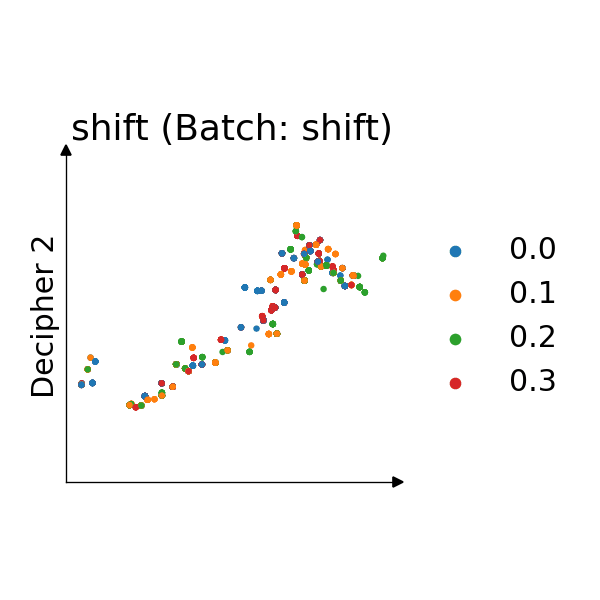

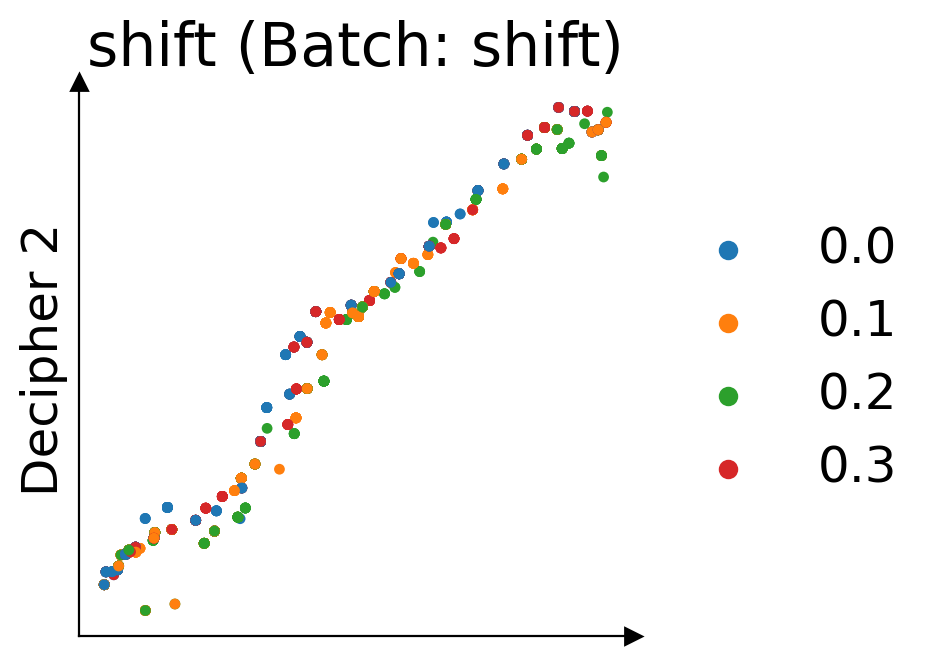

In [37]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc_vz.tl.decipher_train(
    adata1, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

In [56]:
def visualize_shift_latentt(adata):
    decipher_z = adata.obsm["decipher_z"]
    shift_labels = adata.obs["shift"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    sc.pl.embedding(adata, basis="decipher_v", color="shift",
                    show=False, ax=axes[0], size=50)
    sc.pl.embedding(adata, basis="decipher_v", color="latent_t",
                    show=False, ax=axes[1], size=30)
    plt.tight_layout()
    plt.show()

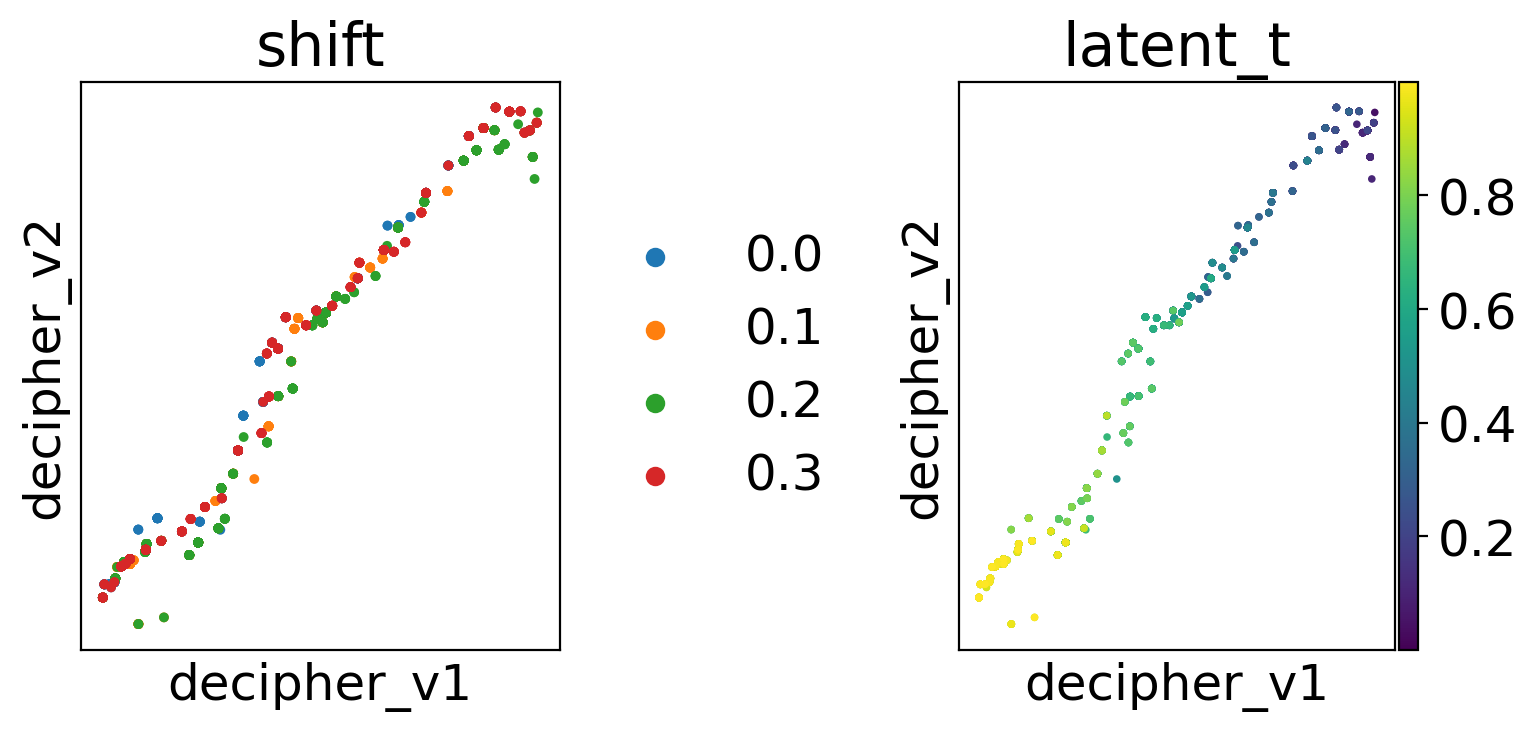

In [39]:
visualize_shift_latentt(adata1)

Epoch 66 (batch 20/20) | | train elbo: 17.70 (last epoch: 17.90) | val ll: 26.90:   7%|▋         | 66/1000 [01:11<16:49,  1.08s/it]2026-06-26 13:24:45,882 | INFO : Early stopping has been triggered.
2026-06-26 13:24:45,888 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 13:24:45,889 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 13:24:45,891 | INFO : Saving decipher model with run_id 2026-06-26-13-24-45-naive-white-dessert.


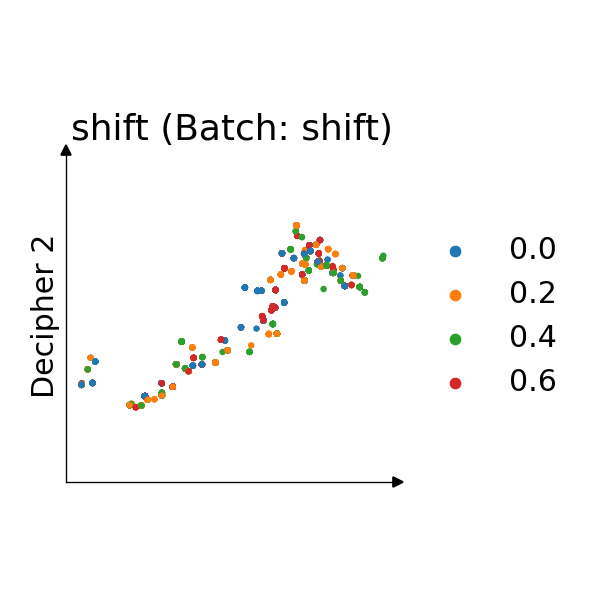

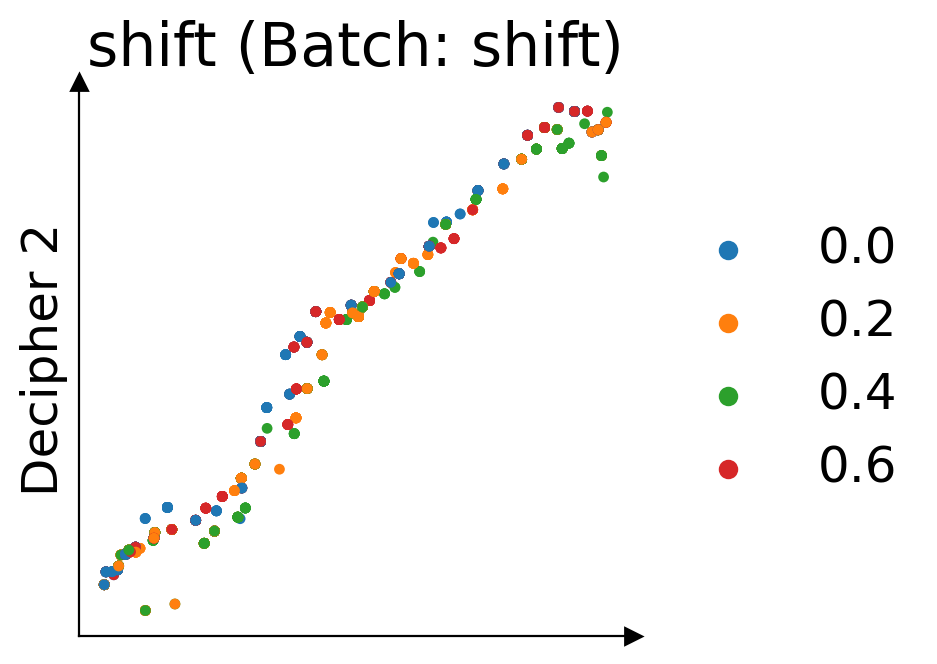

In [41]:
adata2, d2, val2 = run_pipeline("0626_vz_0.20_0.40_0.60.h5ad")

In [43]:
adata2.layers['counts'].shape

(2000, 50)

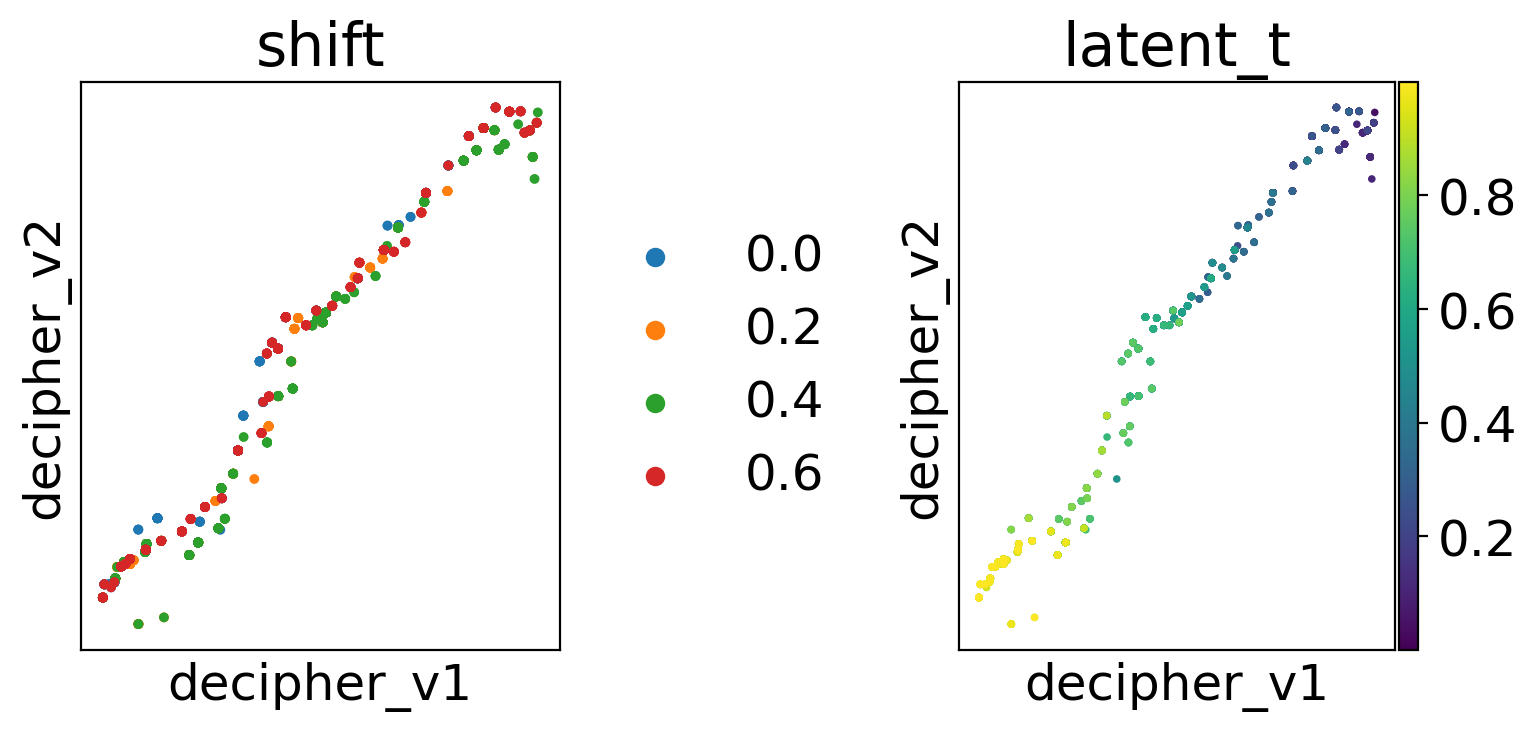

In [42]:
visualize_shift_latentt(adata2)

<Figure size 640x480 with 0 Axes>

v[:,0] vs latent_t: Spearman ρ = -0.944, p = 0.00e+00
v[:,1] vs latent_t: Spearman ρ = -0.942, p = 0.00e+00


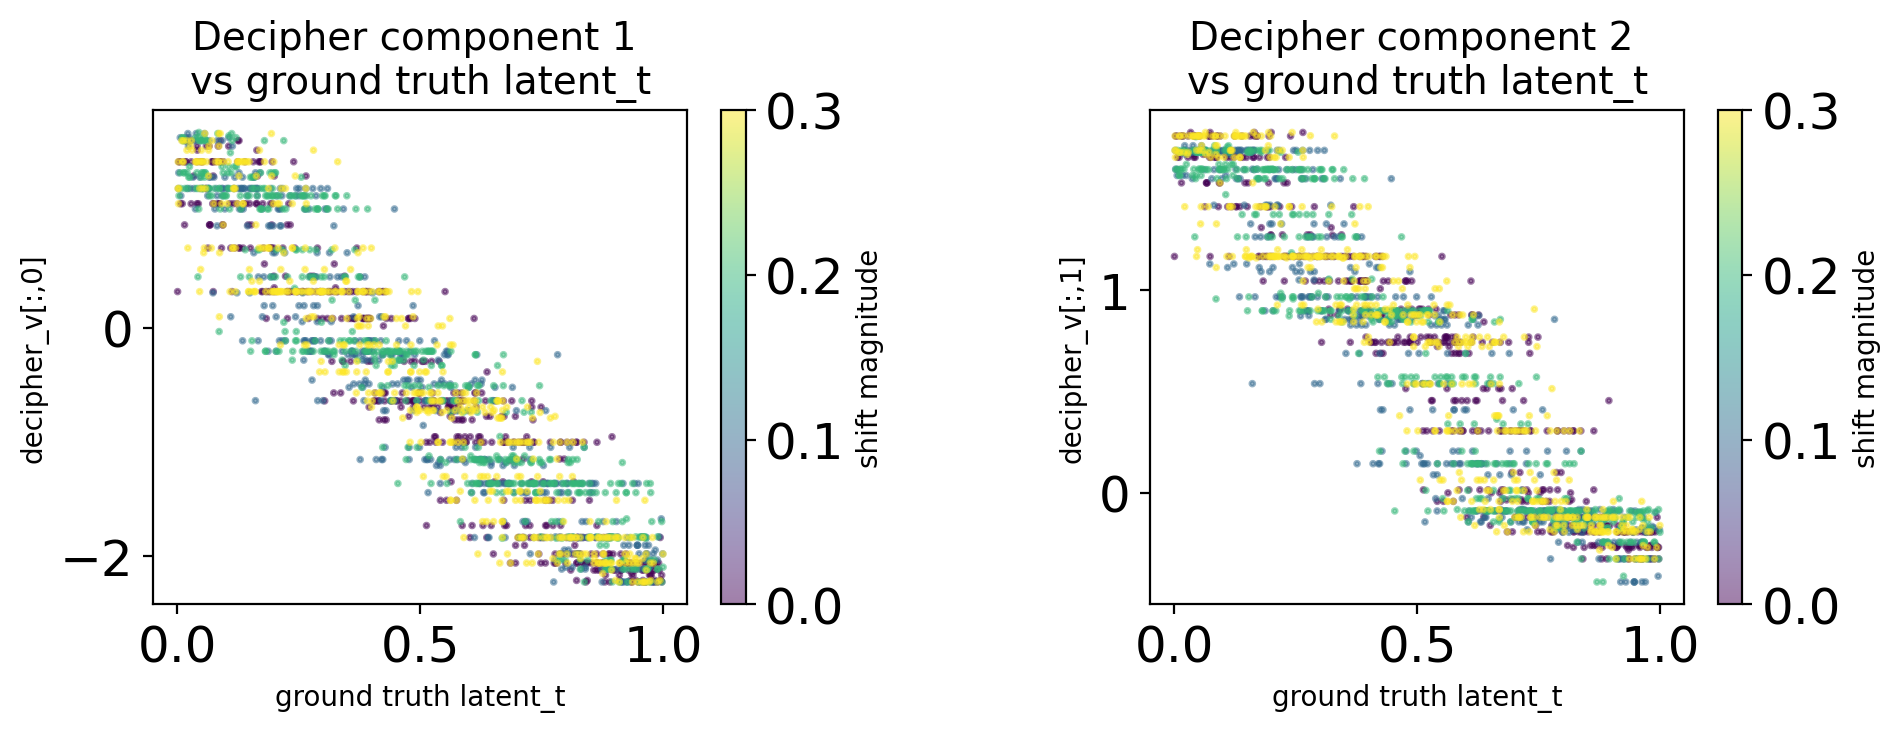

In [ ]:
import scanpy as sc   # scanpy stays as sc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

v = adata1.obsm["decipher_v"]
ground_t = adata1.obs["latent_t"].values

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5*2, 4))
for i in range(v.shape[1]):
    rho, pval = spearmanr(v[:, i], ground_t)
    print(f"v[:,{i}] vs latent_t: Spearman ρ = {rho:.3f}, p = {pval:.2e}")
    ax = axes[i]
    scatter = ax.scatter(                       # renamed from sc → scatter
        ground_t, v[:, i],
        c=adata1.obs["shift"].values, cmap="viridis",
        s=3, alpha=0.5,
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("shift magnitude", fontsize=10)
    ax.set_title(f"Decipher component {i+1} \nvs ground truth latent_t", fontsize=14)
    ax.set_xlabel("ground truth latent_t", fontsize=10)
    ax.set_ylabel(f"decipher_v[:,{i}]", fontsize=10)
plt.tight_layout()
plt.show()

## version 2

Epoch 68 (batch 22/22) | | train elbo: 33.09 (last epoch: 33.41) | val ll: 42.22:   7%|▋         | 68/1000 [00:58<13:18,  1.17it/s]2026-06-26 15:10:28,183 | INFO : Early stopping has been triggered.
2026-06-26 15:10:28,190 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 15:10:28,190 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 15:10:28,191 | INFO : Saving decipher model with run_id 2026-06-26-15-10-28-optical-claret-filet.


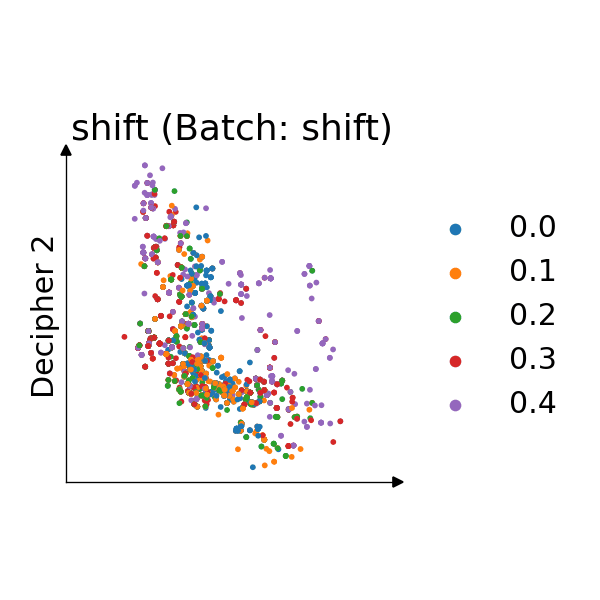

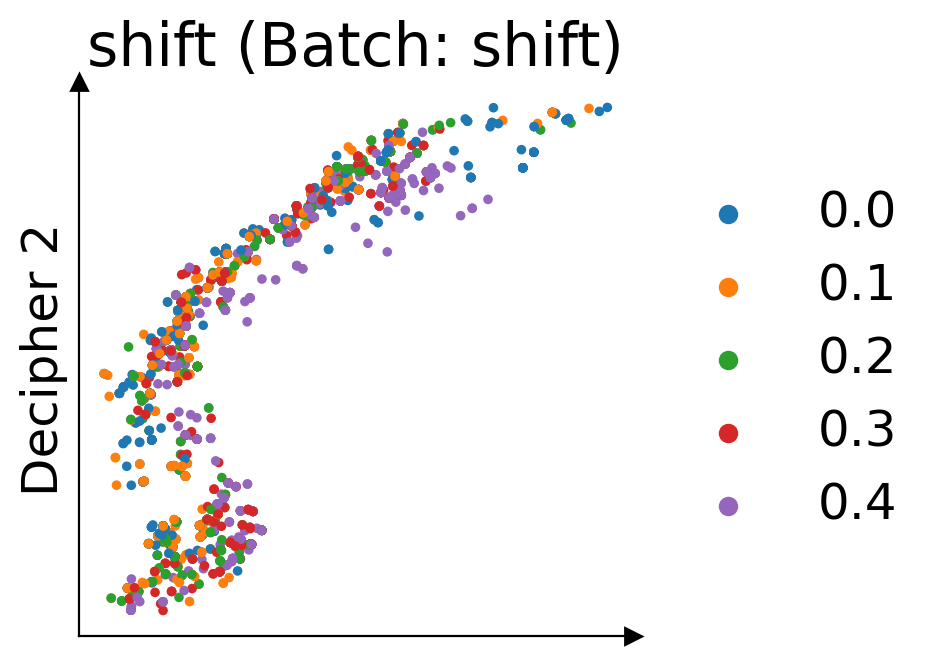

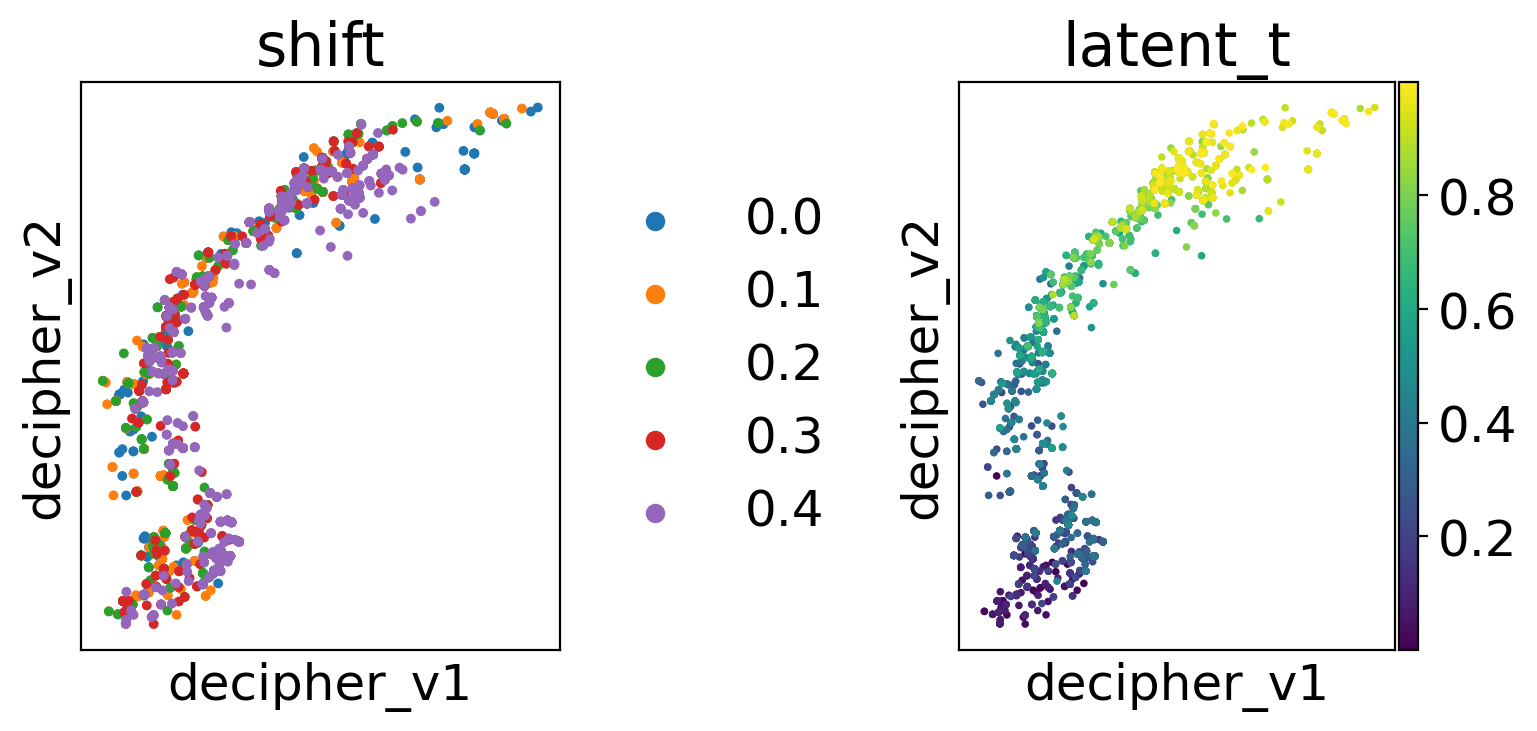

In [ ]:
adata1, d1, val1 = run_pipeline("0626_vz_0.10_0.20_0.30_0.40.h5ad", shift="v-to-z")

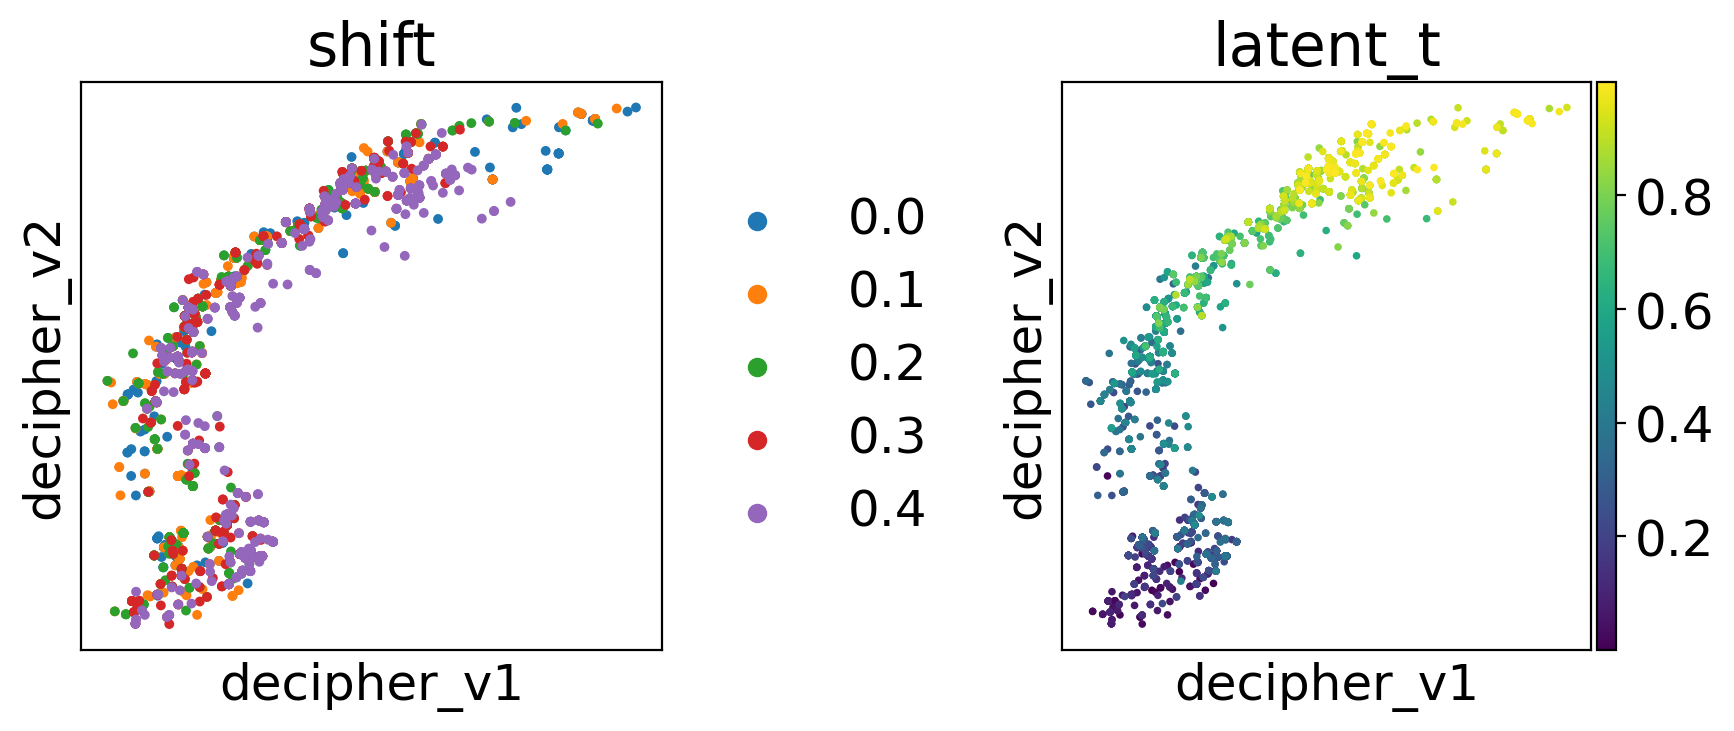

In [57]:
visualize_shift_latentt(adata1)

v[:,0] vs latent_t: Spearman ρ = 0.757, p = 0.00e+00
v[:,1] vs latent_t: Spearman ρ = 0.942, p = 0.00e+00


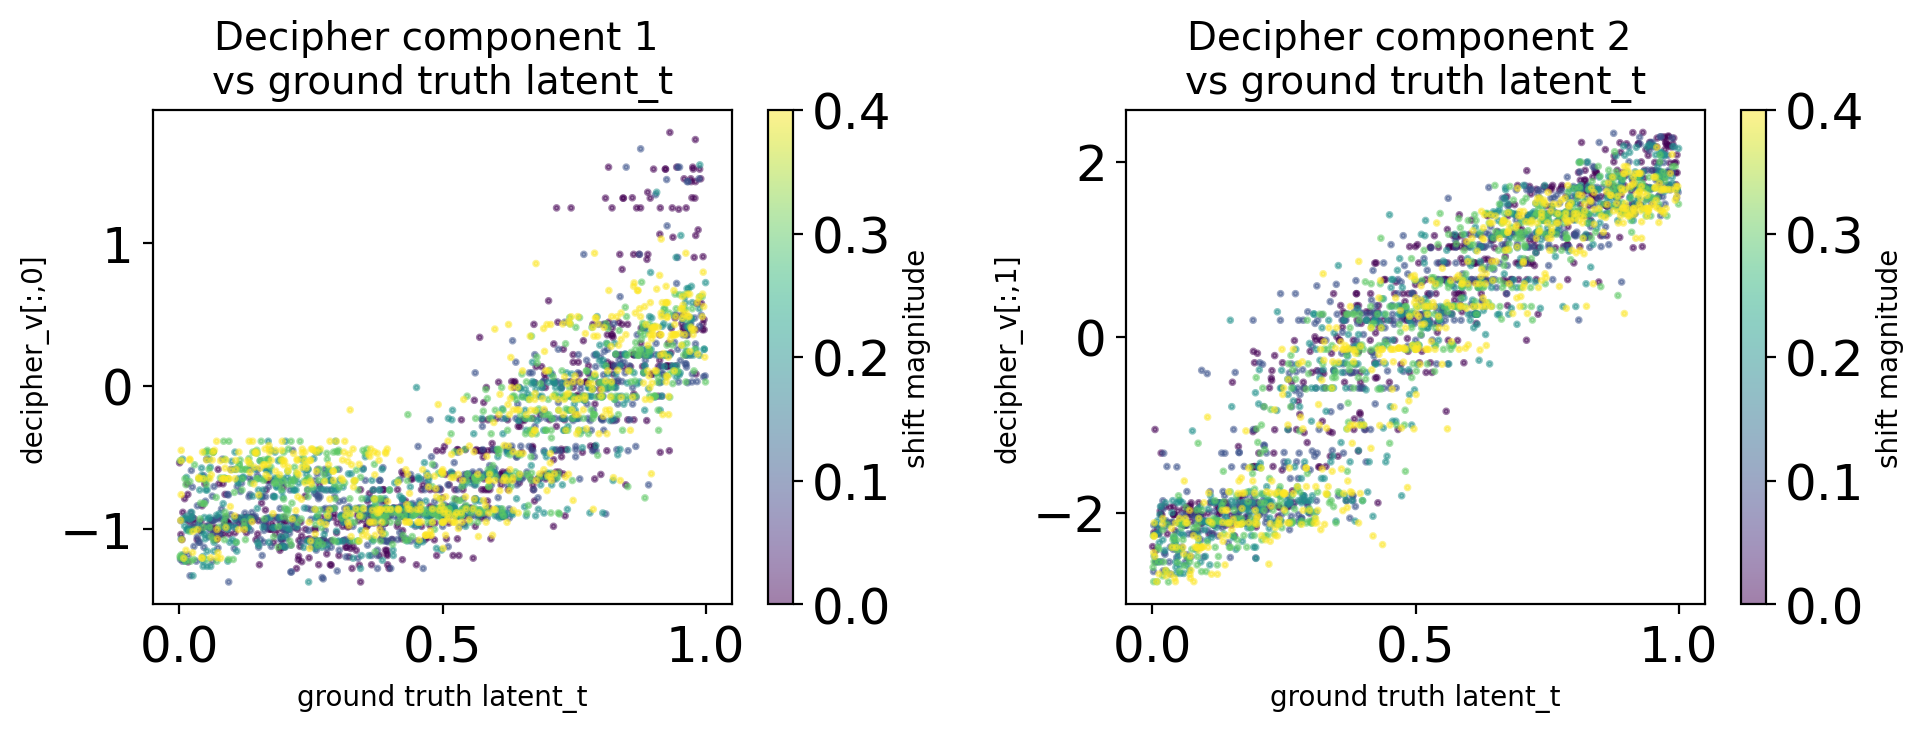

In [58]:
import scanpy as sc   # scanpy stays as sc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

v = adata1.obsm["decipher_v"]
ground_t = adata1.obs["latent_t"].values

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5*2, 4))
for i in range(v.shape[1]):
    rho, pval = spearmanr(v[:, i], ground_t)
    print(f"v[:,{i}] vs latent_t: Spearman ρ = {rho:.3f}, p = {pval:.2e}")
    ax = axes[i]
    scatter = ax.scatter(                       # renamed from sc → scatter
        ground_t, v[:, i],
        c=adata1.obs["shift"].values, cmap="viridis",
        s=3, alpha=0.5,
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("shift magnitude", fontsize=10)
    ax.set_title(f"Decipher component {i+1} \nvs ground truth latent_t", fontsize=14)
    ax.set_xlabel("ground truth latent_t", fontsize=10)
    ax.set_ylabel(f"decipher_v[:,{i}]", fontsize=10)
plt.tight_layout()
plt.show()

In [59]:
import numpy as np
from scipy.stats import spearmanr

results = []
for batch in sorted(adata1.obs["batch"].unique()):
    sub = adata1[adata1.obs["batch"] == batch]
    v = sub.obsm["decipher_v"]
    t = sub.obs["latent_t"].values
    rhos = [abs(spearmanr(v[:, i], t).correlation) for i in range(v.shape[1])]
    results.append({"batch": batch, "shift": sub.obs["shift"].iloc[0], 
                    "max_rho": max(rhos), "v0_rho": rhos[0], "v1_rho": rhos[1]})

import pandas as pd
print(pd.DataFrame(results))

  batch  shift   max_rho    v0_rho    v1_rho
0  0.00    0.0  0.946553  0.848172  0.946553
1  0.10    0.1  0.941113  0.797229  0.941113
2  0.20    0.2  0.942988  0.742798  0.942988
3  0.30    0.3  0.949627  0.688061  0.949627
4  0.40    0.4  0.939064  0.694450  0.939064


v[:,0] vs latent_t: Spearman ρ = 0.944, p = 0.00e+00
v[:,1] vs latent_t: Spearman ρ = 0.044, p = 2.80e-02


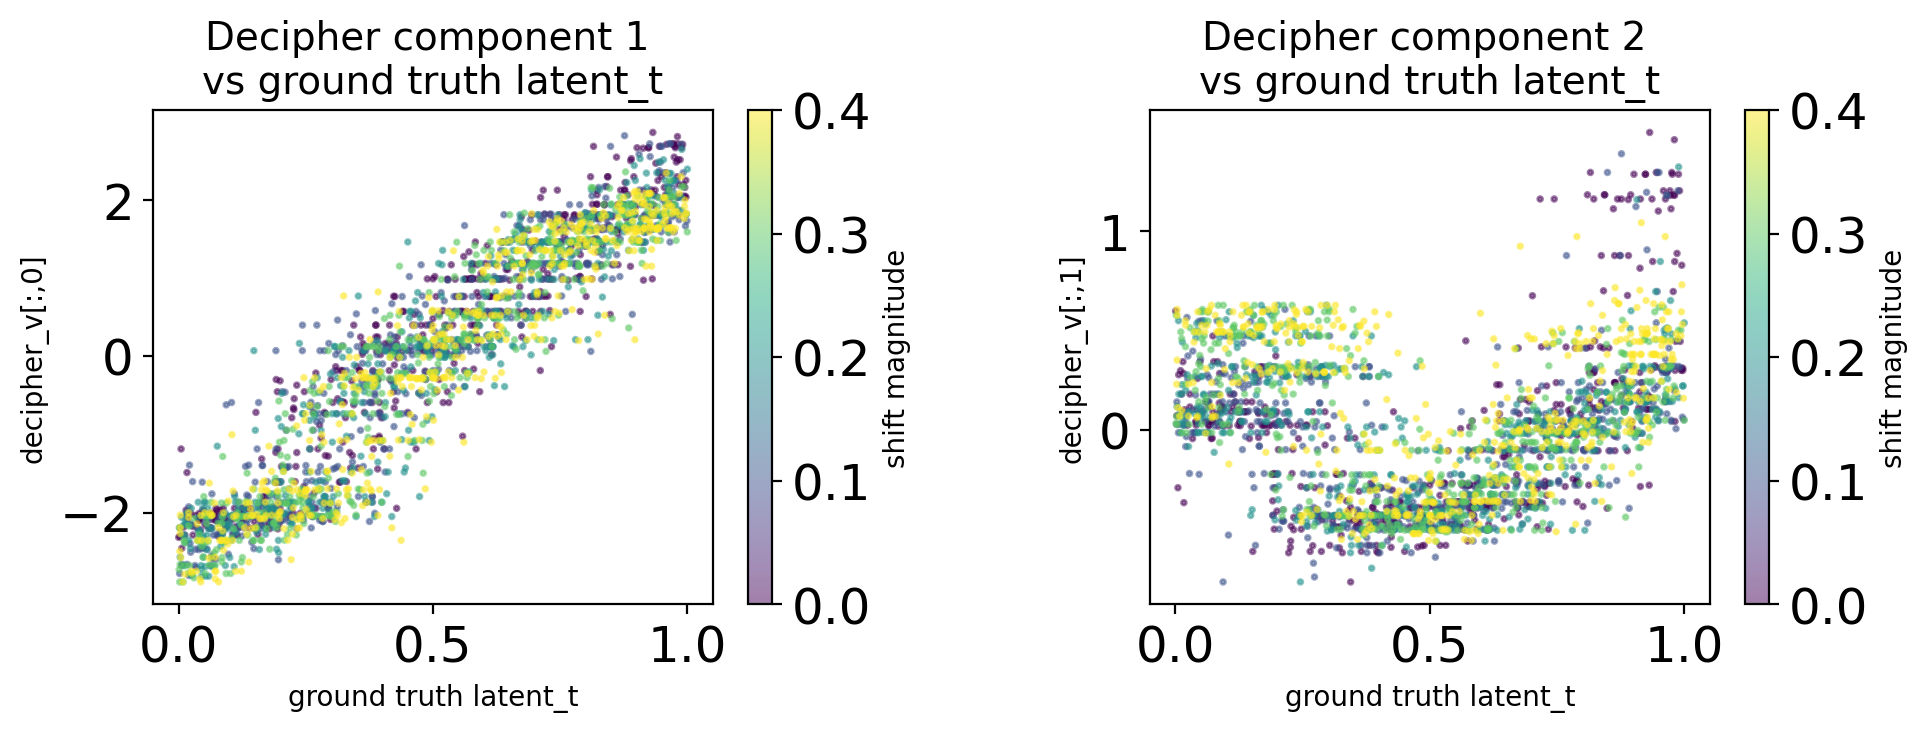

In [60]:
from sklearn.decomposition import PCA

v = adata1.obsm["decipher_v"]
v_rotated = PCA(n_components=2).fit_transform(v)

# now v_rotated[:, 0] is the dominant pseudotime axis

import scanpy as sc   # scanpy stays as sc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

v = v_rotated
ground_t = adata1.obs["latent_t"].values

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5*2, 4))
for i in range(v.shape[1]):
    rho, pval = spearmanr(v[:, i], ground_t)
    print(f"v[:,{i}] vs latent_t: Spearman ρ = {rho:.3f}, p = {pval:.2e}")
    ax = axes[i]
    scatter = ax.scatter(                       # renamed from sc → scatter
        ground_t, v[:, i],
        c=adata1.obs["shift"].values, cmap="viridis",
        s=3, alpha=0.5,
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("shift magnitude", fontsize=10)
    ax.set_title(f"Decipher component {i+1} \nvs ground truth latent_t", fontsize=14)
    ax.set_xlabel("ground truth latent_t", fontsize=10)
    ax.set_ylabel(f"decipher_v[:,{i}]", fontsize=10)
plt.tight_layout()
plt.show()

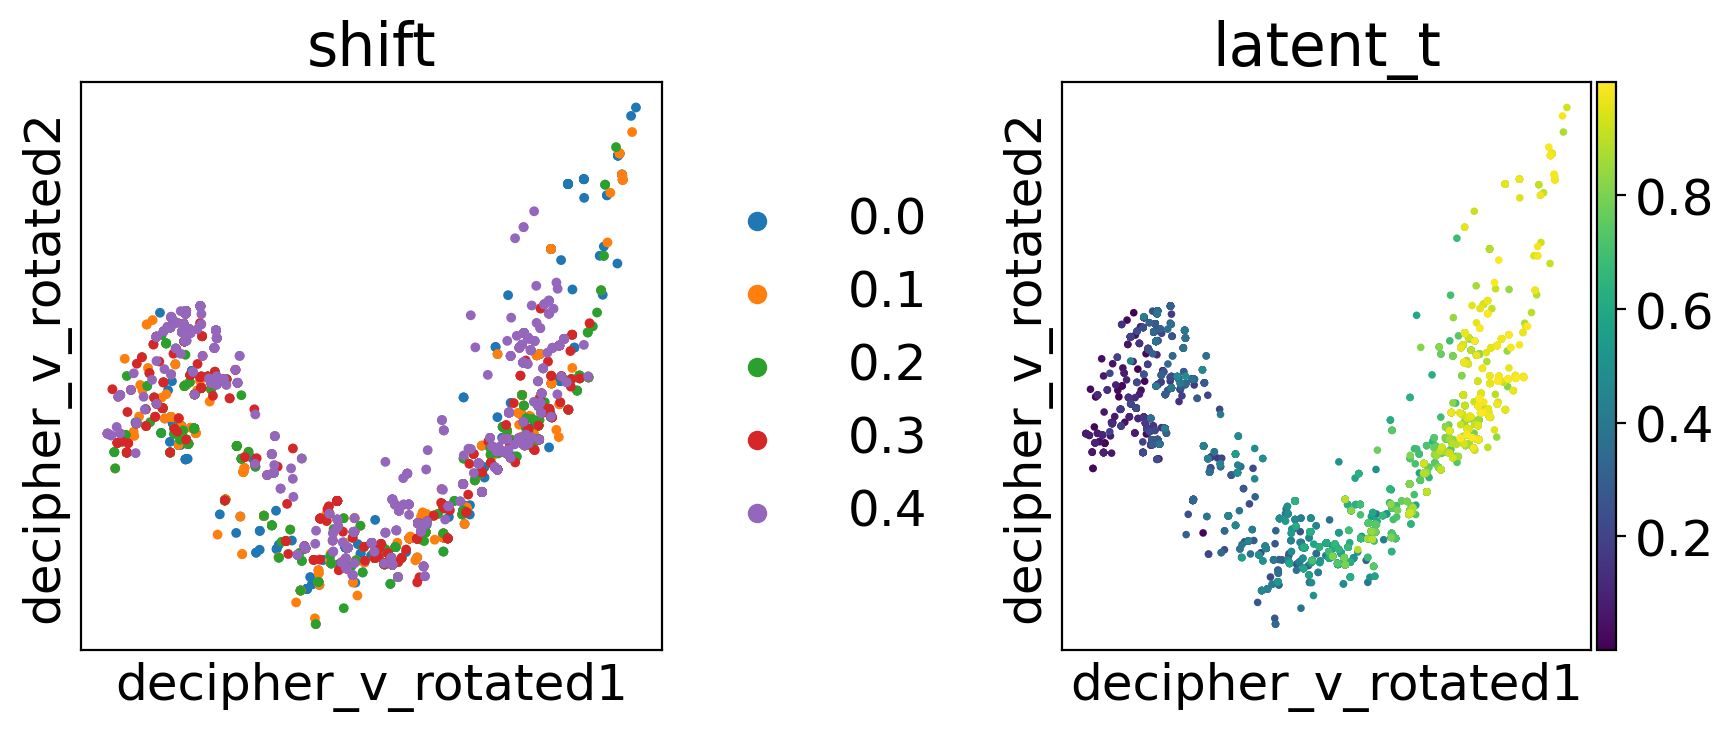

In [66]:
from scipy.stats import spearmanr

v = adata1.obsm["decipher_v"]
v_rotated = PCA(n_components=2).fit_transform(v)
# Order PCs by |Spearman with latent_t|, descending
rhos = [abs(spearmanr(v_rotated[:, i], adata1.obs["latent_t"]).correlation) 
        for i in range(v_rotated.shape[1])]
order = np.argsort(rhos)[::-1]   # largest |ρ| first
v_rotated = v_rotated[:, order]
adata1.obsm["decipher_v_rotated"] = v_rotated

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
sc.pl.embedding(adata1, basis="decipher_v_rotated", color="shift",
                show=False, ax=axes[0], size=50)
sc.pl.embedding(adata1, basis="decipher_v_rotated", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

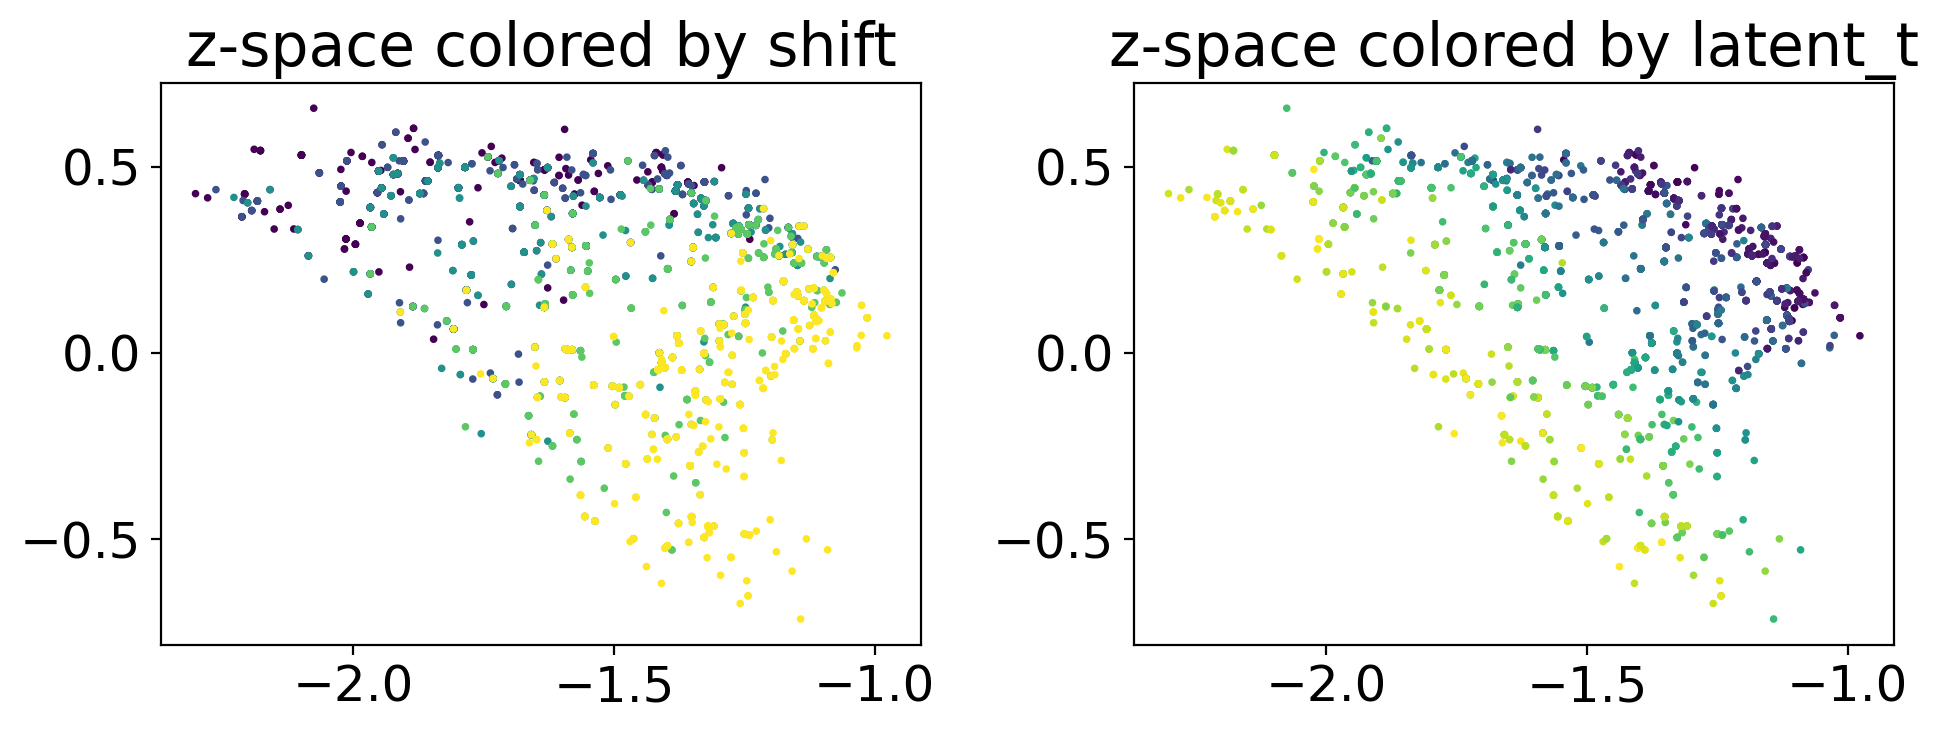

In [67]:
z = adata1.obsm["decipher_z"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(z[:, 0], z[:, 1], c=adata1.obs["shift"].values, cmap="viridis", s=3)
axes[0].set_title("z-space colored by shift")

axes[1].scatter(z[:, 0], z[:, 1], c=adata1.obs["latent_t"].values, cmap="viridis", s=3)
axes[1].set_title("z-space colored by latent_t")

plt.tight_layout()
plt.show()

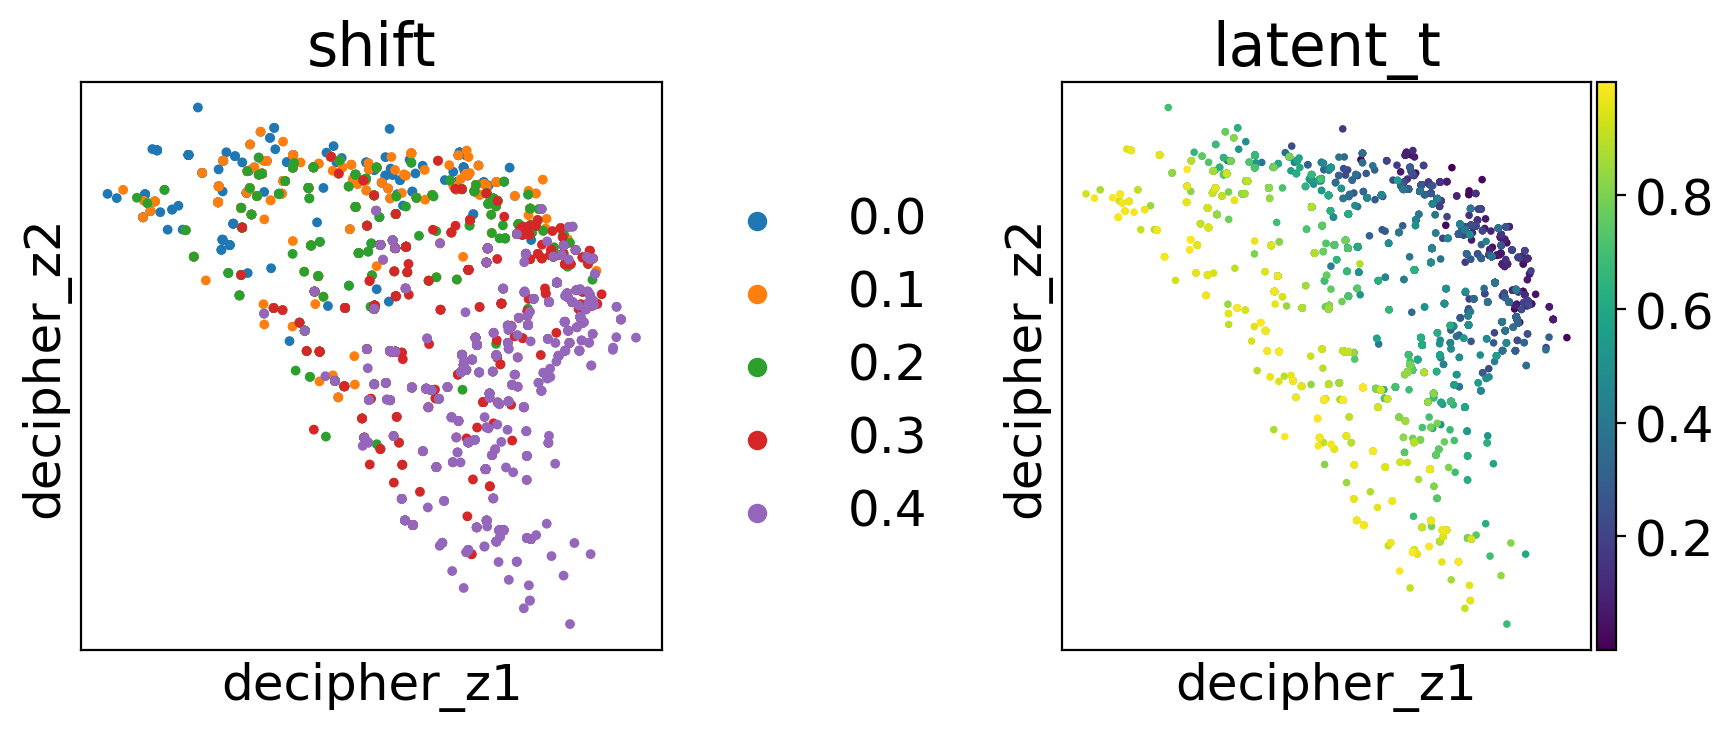

In [69]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
sc.pl.embedding(adata1, basis="decipher_z", color="shift",
                show=False, ax=axes[0], size=50)
sc.pl.embedding(adata1, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [19]:
# 1. Train
#model, val_losses = dc.tl.decipher_train(adata1, batch_key="batch")

# 2. Rotate space — aligns the v components into interpretable axes
dc_vz.tl.decipher_rotate_space(adata1)

# 3. Compute trajectories — this is what populates decipher_time
dc_vz.tl.decipher_trajectory(adata1)

2026-06-26 12:38:07,094 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 12:38:07,096 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.


AttributeError: module 'decipher_vz.tools' has no attribute 'decipher_trajectory'

In [18]:
import scanpy as sc
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Mask NaN decipher_time (cells not on a trajectory)
mask = adata1.obs["decipher_time"].notna()
adata_valid = adata1[mask]

learned_t = adata_valid.obs["decipher_time"].values
ground_t  = adata_valid.obs["latent_t"].values

# Spearman correlation
rho, pval = spearmanr(learned_t, ground_t)
print(f"Spearman rho: {rho:.3f}, p={pval:.2e}")

# Scatter plot
fig, ax = plt.subplots(figsize=(4, 4))
sc_plot = ax.scatter(ground_t, learned_t, c=adata_valid.obs["shift"].values,
                     cmap="viridis", s=5, alpha=0.6)
plt.colorbar(sc_plot, ax=ax, label="shift magnitude")
ax.set_xlabel("ground truth latent_t")
ax.set_ylabel("decipher_time")
ax.set_title(f"Spearman ρ = {rho:.3f}")
plt.tight_layout()
plt.show()

KeyError: 'decipher_time'

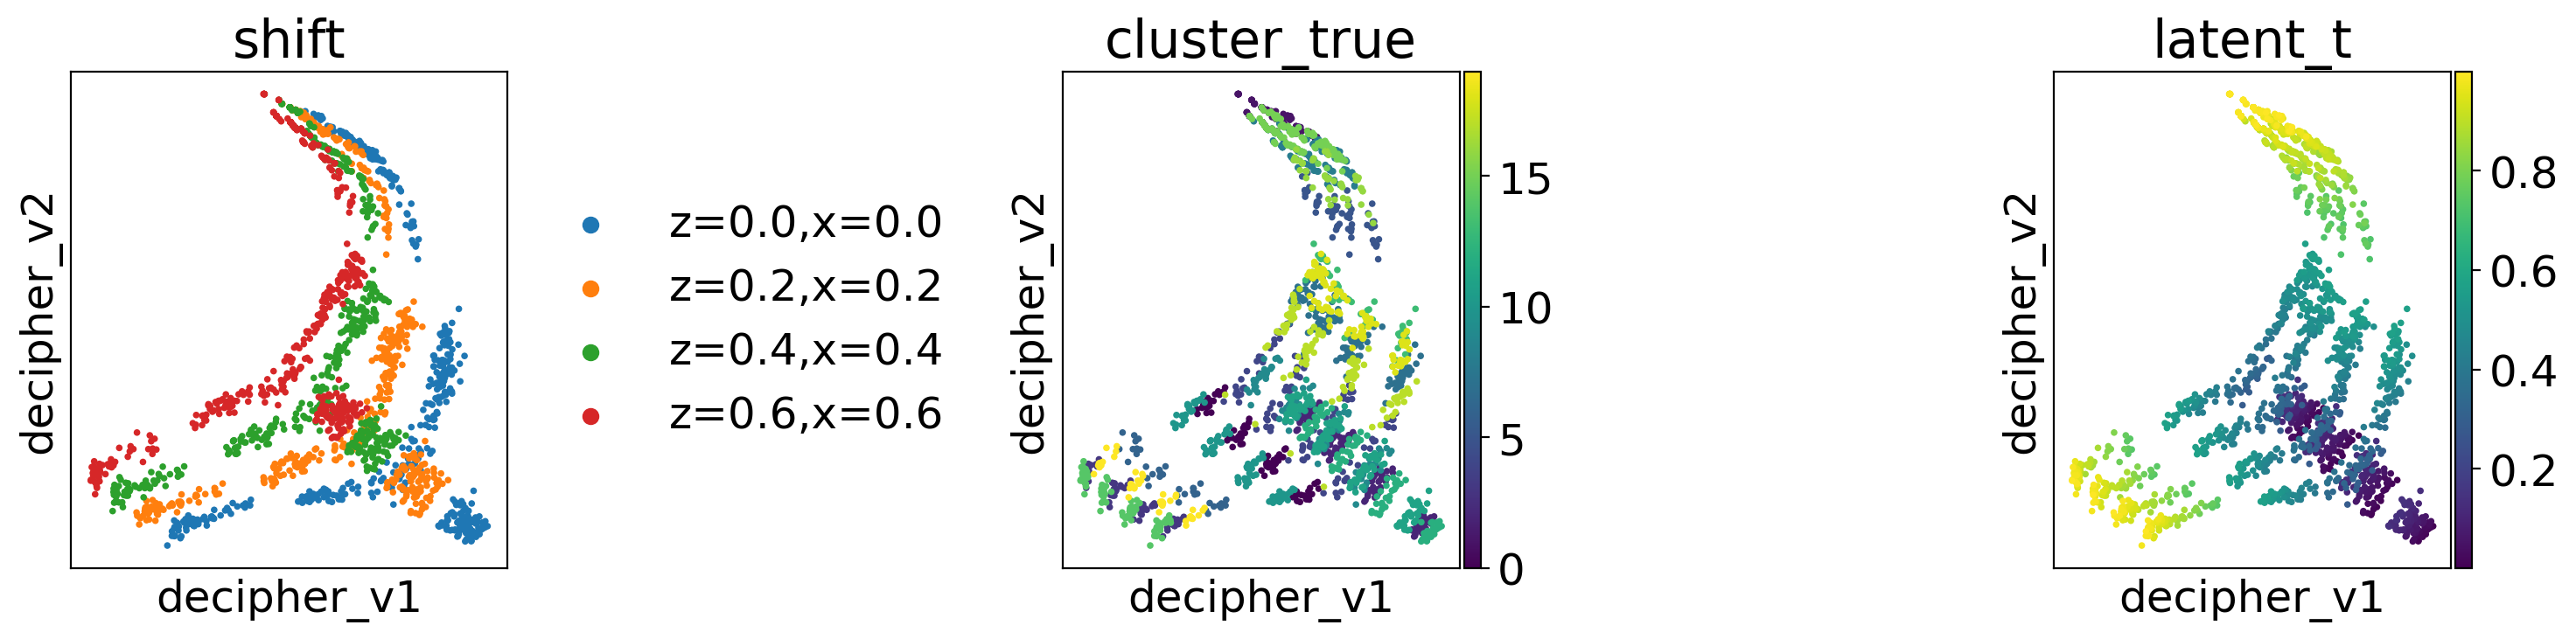

In [ ]:
decipher_z = adata1.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
adata1.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in adata1.obs["shift"].unique():
    mask = adata1.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        adata1.obs["cluster_true"][mask],
        adata1.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = adata1.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(adata1, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [23]:
folder = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/z-to-x"
file = "delta_0.40_0.80_1.20.h5ad"
adata3 = sc.read_h5ad(f"{folder}/{file}")
adata3.uns["color_palette"] = None
color_palette = None

Epoch 248 (batch 20/20) | | train elbo: 134.45 (last epoch: 134.61) | val ll: 145.00:  25%|██▍       | 248/1000 [12:31<37:58,  3.03s/it]2026-06-15 18:40:28,070 | INFO : Early stopping has been triggered.


2026-06-15 18:40:28,451 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-15 18:40:28,460 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-15 18:40:28,480 | INFO : Saving decipher model with run_id 2026-06-15-18-40-28-recursive-tranquil-ice.


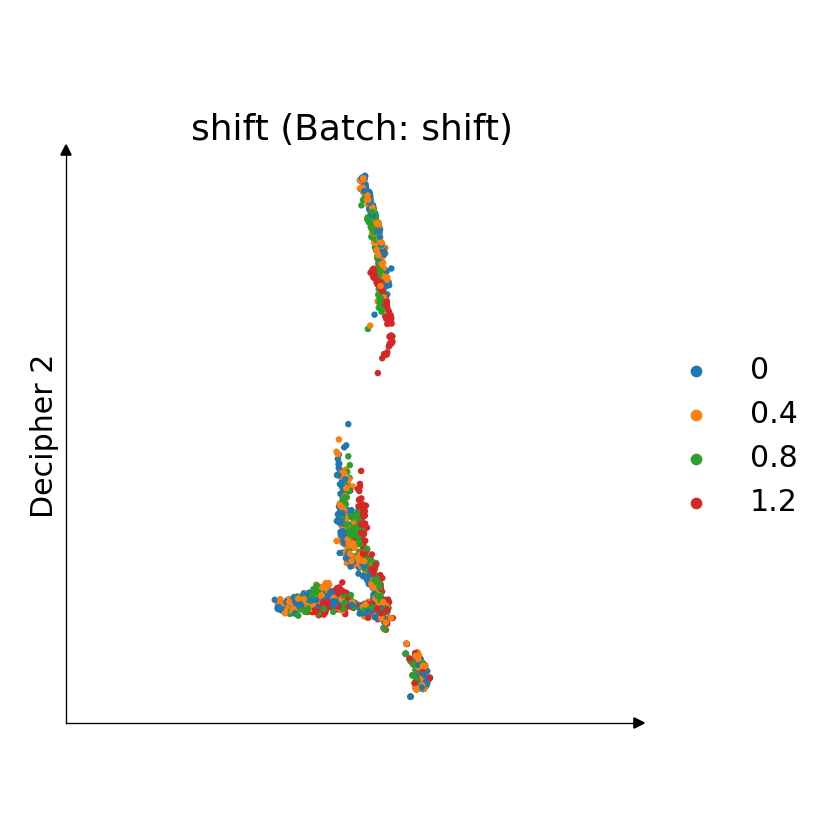

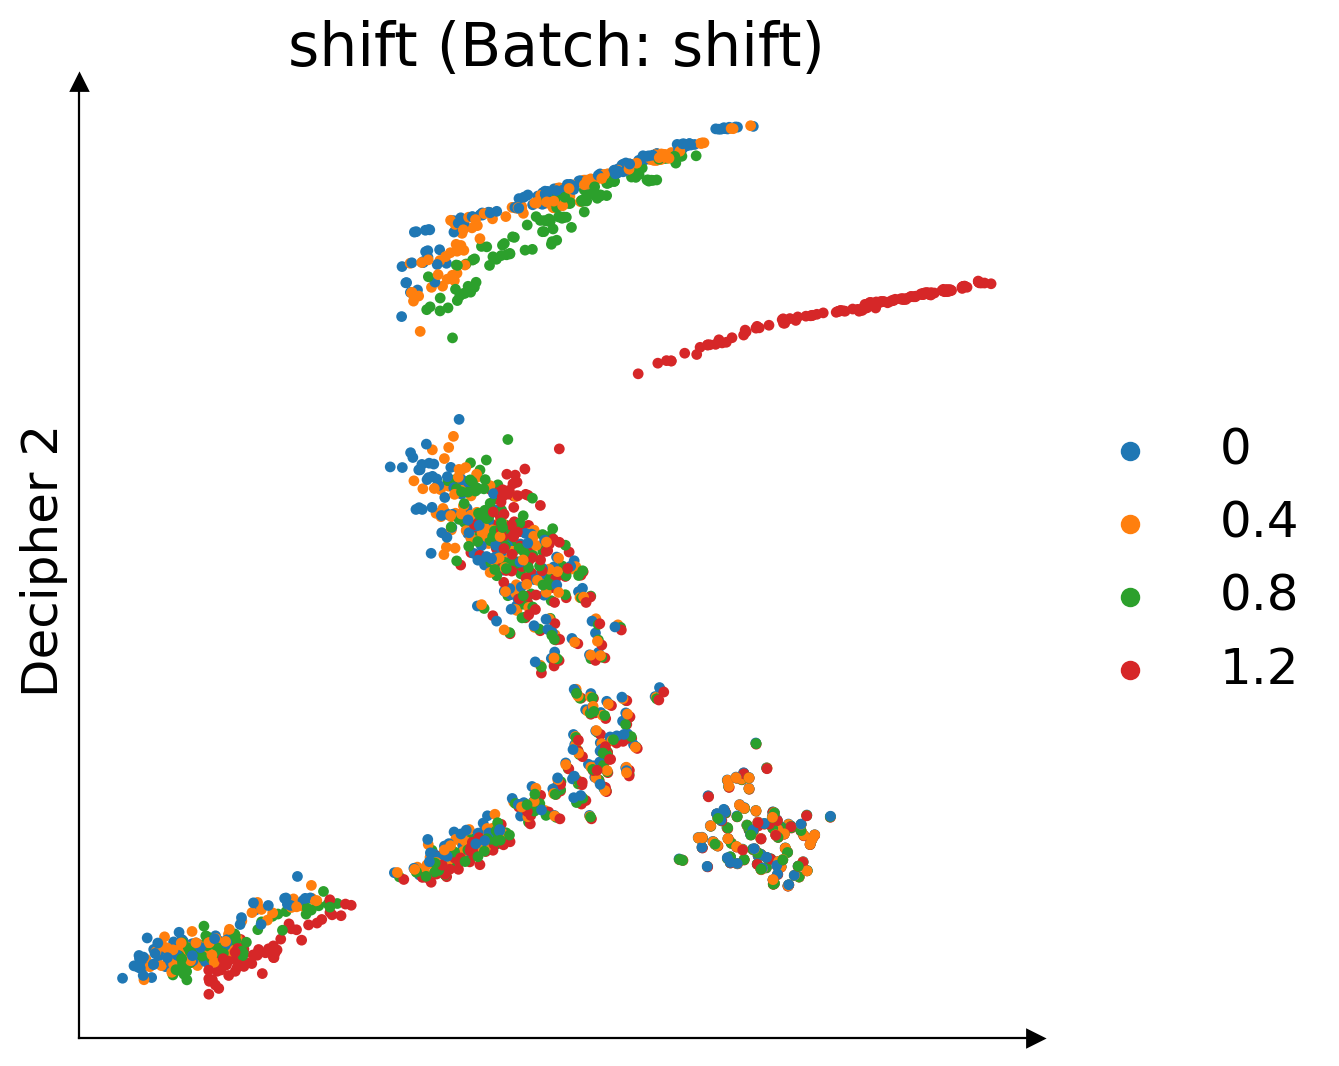

In [24]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d3, val3 = dc_vz.tl.decipher_train(
    adata3, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

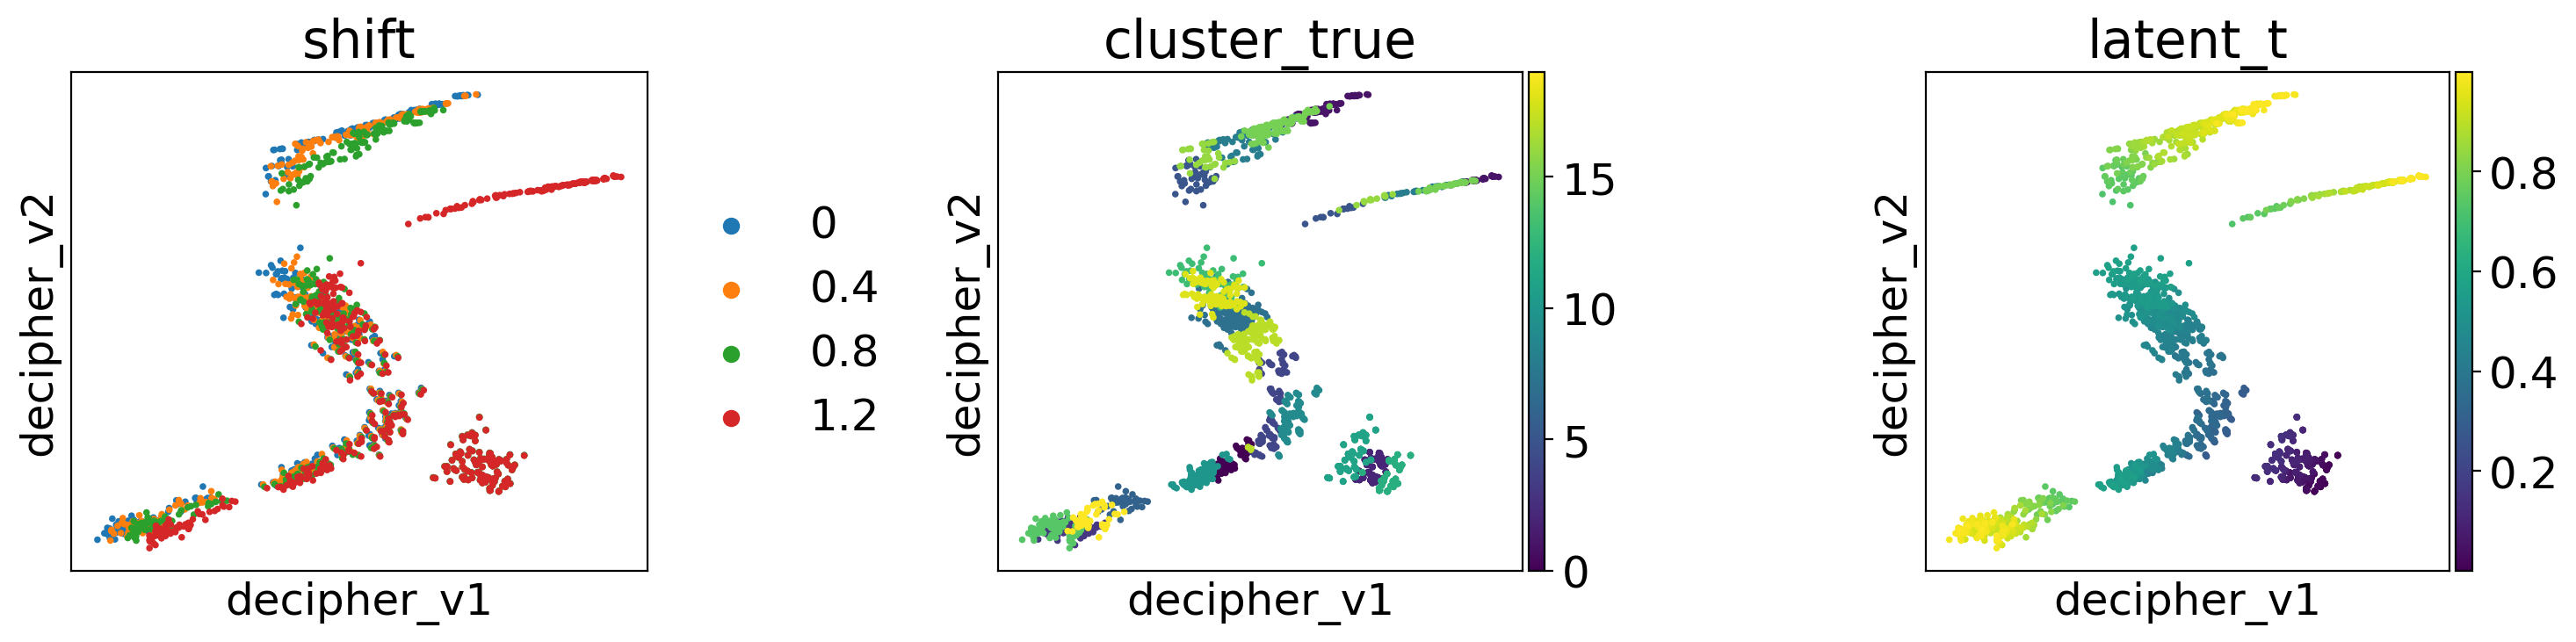

In [25]:
temp = adata3.copy()

decipher_z = temp.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
temp.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in temp.obs["shift"].unique():
    mask = temp.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        temp.obs["cluster_true"][mask],
        temp.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = temp.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(temp, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

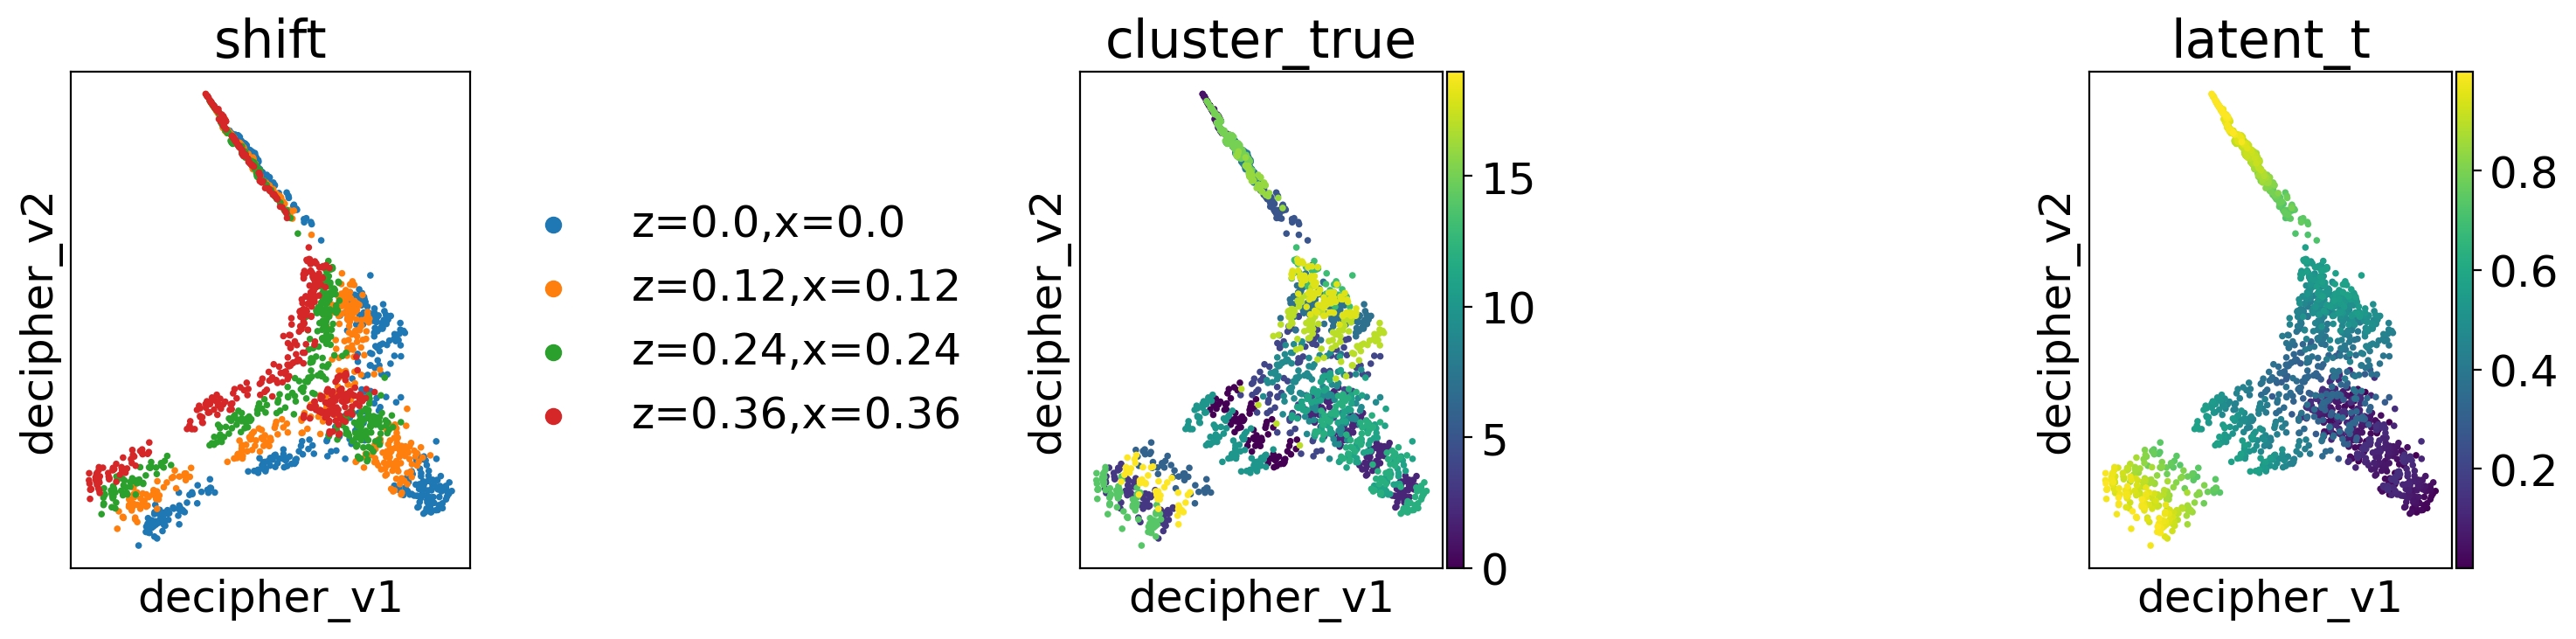

In [22]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples


temp = adata2.copy()

decipher_z = temp.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
temp.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in temp.obs["shift"].unique():
    mask = temp.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        temp.obs["cluster_true"][mask],
        temp.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = temp.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(temp, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [ ]:
file = "v_to_z_0.12_0.24_0.36.h5ad"
adata2 = sc.read_h5ad(f"{folder}/{file}")
adata2.uns["color_palette"] = None
color_palette = None

In [18]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc.tl.decipher_train(
    adata1, decipher_config, plot_kwargs= {"color": "shift"}, 
    plot_every_k_epochs=5,
)

2026-06-15 16:36:46,356 | INFO : Added `.obs['decipher_split']`: the Decipher train/validation split.
 200 cells in validation set.
  0%|          | 0/1000 [00:00<?, ?it/s]

ERROR index_select(): self indexing axis dim should be positive
                                  Trace Shapes:           
                                   Param Sites:           
                         decipher$$$dummy_param       0   
                    decipher$$$batch_emb.weight   0   8   
      decipher$$$encoder_x_to_z.layers.0.weight 128  50   
        decipher$$$encoder_x_to_z.layers.0.bias     128   
      decipher$$$encoder_x_to_z.layers.1.weight  20 128   
        decipher$$$encoder_x_to_z.layers.1.bias      20   
 decipher$$$encoder_x_to_z.batch_norms.0.weight     128   
   decipher$$$encoder_x_to_z.batch_norms.0.bias     128   
     decipher$$$encoder_zx_to_v.layers.0.weight 128  60   
       decipher$$$encoder_zx_to_v.layers.0.bias     128   
     decipher$$$encoder_zx_to_v.layers.1.weight   4 128   
       decipher$$$encoder_zx_to_v.layers.1.bias       4   
decipher$$$encoder_zx_to_v.batch_norms.0.weight     128   
  decipher$$$encoder_zx_to_v.batch_norms.0.bias    

In [68]:
# Before choosing what to correct for, measure which covariates actually drive
# separation in the v-space. High silhouette = strong separation = bigger effect.

from sklearn.metrics import silhouette_score

v = adata_combined.obsm['decipher_v'].copy()

# Only score covariates with at least 2 unique values and no NaNs
covariates_to_score = {
    "shift"   : adata_combined.obs["shift"].astype(str),
}

print("\n── Silhouette scores in v-space (higher = stronger separation) ──────────")
silhouette_results = {}
for name, labels in covariates_to_score.items():
    # Drop NaN rows
    mask = labels != "nan"
    if labels[mask].nunique() < 2:
        print(f"  {name:<20} skipped (< 2 unique values)")
        continue
    score = silhouette_score(v[mask], labels[mask], sample_size=5000, random_state=42)
    silhouette_results[name] = score
    print(f"  {name:<25} silhouette = {score:.4f}")  



── Silhouette scores in v-space (higher = stronger separation) ──────────
  shift                     silhouette = -0.0487
